# WhyWatt — NREL end-use load profiles review (Phase 7 §6)

**What changes when the hourly energy balance uses NREL ResStock shapes instead of
`data/rates/device_load_shapes.json`.**

- **New:** `data/loads/end_use_profiles.json` — ResStock 2025 Release 1 (AMY2018), per CEC zone ×
  end use × month × 24 clock hours (`scripts/build_load_profiles.py`, `docs/NREL_LoadProfiles_Plan.md`).
- **Old:** one 24-h shape per device category for every month and zone; everyday use flat (1/24);
  a heat pump used the *heating* shape all year; the transportation-slot EV (`ElectricVehicle`)
  had no shape and fell back to flat — home EV charging spread evenly over the day, much of it at
  midday on solar.
- §1 compares the shapes; §2 re-runs the regression base cases with the old shapes and the new
  ones and compares self-use, battery discharge, peak-hour grid import and the 20-year result.
- The "old" run rebuilds the old behaviour exactly: the same 24-h shape every month, flat
  everyday use, the heat pump on the heating shape year-round.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src")); sys.path.insert(0, str(ROOT / "scripts"))
import load_profiles as LPM
from load_profiles import LoadProfiles, HP_HEATING, HP_COOLING
from solar_loader import DST_MONTHS

NEW = LPM.get_loader()
old_raw = json.loads((ROOT / "data/rates/device_load_shapes.json").read_text(encoding="utf-8"))["profiles"]
OLD_CAT = {k: np.asarray(v, float) / np.sum(v) for k, v in old_raw.items()}

# Old behaviour per device key (model.DEVICE_ACC_CATEGORY before §6; heat pump = heating shape all year)
OLD_BY_KEY = {"LightsAndPlugs": "baseload", "InductionCooktop": "baseload", "ElectricOven": "baseload",
              "HeatPumpDryer": "baseload", "Dishwasher": "baseload", "CentralAC": "hvac_cool",
              HP_HEATING: "hvac_heat", HP_COOLING: "hvac_heat", "HeatPumpWaterHeater": "hpwh",
              "EVCharger": "ev", "PhysicsEVCharger": "ev"}
# NB: ElectricVehicle (transportation slot) had no entry before §6 → the flat default.

class OldProfiles(LoadProfiles):
    def shape(self, key, month):
        return OLD_CAT[OLD_BY_KEY.get(key, "flat")]
    def heat_pump_shape(self, month, heating_share):
        return OLD_CAT["hvac_heat"]

OLD = OldProfiles(zone_key="CA_CZ4", level="zone", end_uses={}, source="device_load_shapes.json")
PEAK = np.zeros(24, bool); PEAK[16:21] = True
DAYS = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
print(NEW.for_zone("CA_CZ4").source)

NREL ResStock 2025.1 (AMY2018) · built 2026-09-24


## 1 · Shapes — old vs new (CZ4 San José, clock time)

January and July, per device.

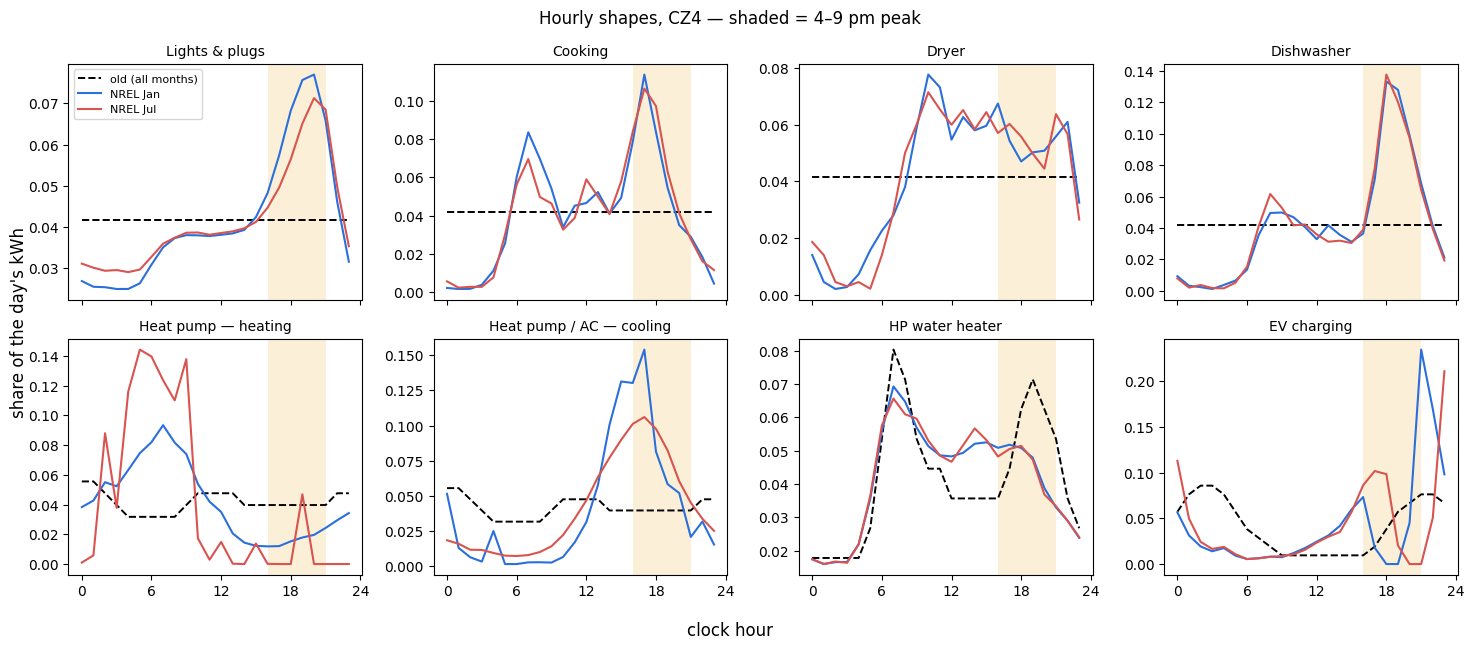

In [2]:
KEYS = [("LightsAndPlugs", "Lights & plugs"), ("InductionCooktop", "Cooking"),
        ("HeatPumpDryer", "Dryer"), ("Dishwasher", "Dishwasher"), (HP_HEATING, "Heat pump — heating"),
        (HP_COOLING, "Heat pump / AC — cooling"), ("HeatPumpWaterHeater", "HP water heater"),
        ("EVCharger", "EV charging")]
lp = NEW.for_zone("CA_CZ4")
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True)
for ax, (key, label) in zip(axes.flat, KEYS):
    ax.axvspan(16, 21, color="#f4d58d", alpha=.35, lw=0)
    ax.plot(OLD.shape(key, 0), "k--", lw=1.4, label="old (all months)")
    ax.plot(lp.shape(key, 0), color="#2a6fdb", label="NREL Jan")
    ax.plot(lp.shape(key, 6), color="#d9534f", label="NREL Jul")
    ax.set_title(label, fontsize=10); ax.set_xticks(range(0, 25, 6))
axes[0, 0].legend(fontsize=8); fig.supxlabel("clock hour"); fig.supylabel("share of the day's kWh")
fig.suptitle("Hourly shapes, CZ4 — shaded = 4–9 pm peak"); plt.tight_layout(); plt.show()

### 4–9 pm share of each device's energy (CZ4)

Flat = 5/24 = 20.8 %.

In [3]:
rows = []
for key, label in KEYS:
    rows.append({"device": label, "old": OLD.shape(key, 0)[PEAK].sum(),
                 "NREL Jan": lp.shape(key, 0)[PEAK].sum(), "NREL Jul": lp.shape(key, 6)[PEAK].sum(),
                 "EV unmanaged Jul": lp.end_uses["ev_unmanaged"][6][PEAK].sum() if key == "EVCharger" else np.nan})
peak_tbl = pd.DataFrame(rows).set_index("device")
(peak_tbl * 100).round(1)

,old,NREL Jan,NREL Jul,EV unmanaged Jul
device,,,,
Lights & plugs,20.8,32.6,28.7,NaN
Cooking,20.8,36.5,39.1,NaN
Dryer,20.8,27.0,26.8,NaN
Dishwasher,20.8,46.8,47.2,NaN
Heat pump — heating,19.8,7.7,4.7,NaN
Heat pump / AC — cooling,19.8,47.6,44.8,NaN
HP water heater,27.7,24.0,23.5,NaN
EV charging,19.0,13.6,30.6,49.1


### Zone spread — lights & plugs and cooling peak share across the 16 zones

In [4]:
zrows = []
for z in range(1, 17):
    p = NEW.for_zone(f"CA_CZ{z}")
    zrows.append({"zone": f"CZ{z}", "lights_plugs Jan": p.shape("LightsAndPlugs", 0)[PEAK].sum(),
                  "lights_plugs Jul": p.shape("LightsAndPlugs", 6)[PEAK].sum(),
                  "cooling Jul": p.shape(HP_COOLING, 6)[PEAK].sum(),
                  "heating Jan": p.shape(HP_HEATING, 0)[PEAK].sum(),
                  "cooling peak hr Jul": int(np.argmax(p.shape(HP_COOLING, 6)))})
(pd.DataFrame(zrows).set_index("zone") * [100, 100, 100, 100, 1]).round(1)

,lights_plugs Jan,lights_plugs Jul,cooling Jul,heating Jan,cooling peak hr Jul
zone,,,,,
CZ1,32.4,28.5,47.6,11.9,17
CZ2,32.6,28.9,50.8,10.3,17
CZ3,32.6,28.7,49.5,9.2,17
CZ4,32.6,28.7,44.8,7.7,17
CZ5,32.8,29.0,40.8,4.0,17
CZ6,32.6,28.9,34.9,3.7,16
CZ7,33.1,29.2,34.6,2.4,16
CZ8,32.6,28.9,34.6,3.8,16
CZ9,32.6,28.9,35.2,4.2,16


## 2 · Regression base cases — old shapes vs NREL shapes

Each base case is run twice through the real headless pipeline (`ui.sim.run_simulation`), once
with the old shapes swapped in. Final-year energy flows (kWh/yr, the journey fully built) and the 20-year cockpit numbers.

In [5]:
import run_regression as RR
import ui.state as S
from ui.sim import run_simulation, extract_metrics

class OldLoader:
    def resolve(self, zipcode): return OLD

def run_case(values, old):
    saved = LPM._LOADER
    LPM._LOADER = OldLoader() if old else None
    try:
        S.reset_to_defaults(); S.apply_config(values)
        model, df = run_simulation()
        m = extract_metrics(model, df)
    finally:
        LPM._LOADER = saved
    h = model.journey_home
    last = lambda hist: (float(np.sum(hist[-1])) if hist and hist[-1] is not None else np.nan)
    return {"solar direct": last(h.solar_direct_history), "battery discharge": last(h.battery_discharge_history),
            "grid import": last(h.grid_import_kwh_history), "grid peak": last(h.grid_peak_kwh_history),
            "home load 4-9pm": (np.asarray(h.home_load_hourly_history[-1])[:, 16:21].sum(axis=1) @ DAYS
                                if h.home_load_hourly_history and h.home_load_hourly_history[-1] is not None else np.nan),
            "opex delta": m["cockpit"].get("opex_delta"), "journey bill": m["cockpit"].get("journey_cumulative_opex")}

cases = RR.discover_cases()
out = []
for stem, env in cases.items():
    o, n = run_case(env["values"], True), run_case(env["values"], False)
    out.append({"case": stem, **{f"{k} old": o[k] for k in o}, **{f"{k} new": n[k] for k in n}})
res = pd.DataFrame(out).set_index("case")
golden = json.loads((ROOT / "tests/regression/golden.json").read_text(encoding="utf-8"))
golden = golden.get("cases", golden)
mismatch = [c for c in res.index if golden[c]["cockpit"]["opex_delta"] != res.at[c, "opex delta old"]]
print(len(res), "cases; old-shape rerun reproduces the committed golden:", not mismatch, mismatch)

Could not check jupyter-widgets extensions.
Traceback (most recent call last):
  File "D:\vijay\MyDocuments\hes\.venv\Lib\site-packages\solara\checks.py", line 201, in check_jupyter
    python_executable = server_python or get_server_python_executable(silent)
                                         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^
  File "D:\vijay\MyDocuments\hes\.venv\Lib\site-packages\solara\checks.py", line 155, in get_server_python_executable
    pythons = [getcmdline(server["pid"]) for server in servers]
               ~~~~~~~~~~^^^^^^^^^^^^^^^
  File "D:\vijay\MyDocuments\hes\.venv\Lib\site-packages\solara\checks.py", line 135, in getcmdline
    return subprocess.check_output(["wmic", "process", "get", "commandline", "/format:list"]).split(b"\n")[0].split(b" ")[0].decode("utf-8")
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 472, in check_output
    return run(*popenargs, stdout=PIP

32

cases; old-shape rerun reproduces the committed golden:

True

[]

In [6]:
flows = ["home load 4-9pm", "solar direct", "battery discharge", "grid import", "grid peak"]
view = pd.DataFrame({f"{k} Δ%": (res[f"{k} new"] / res[f"{k} old"] - 1) * 100 for k in flows})
view.insert(0, "grid peak old kWh", res["grid peak old"])
view.round(1)

,grid peak old kWh,home load 4-9pm Δ%,solar direct Δ%,battery discharge Δ%,grid import Δ%,grid peak Δ%
case,,,,,,
01_pge_no_solar,NaN,NaN,NaN,NaN,NaN,NaN
02_pge_solar,NaN,NaN,-5.0,3.5,3.7,NaN
03_sce_no_solar,NaN,NaN,NaN,NaN,NaN,NaN
04_sce_solar,NaN,NaN,-4.7,2.2,11.5,NaN
05_ca_average_no_solar,NaN,NaN,NaN,NaN,NaN,NaN
06_ca_average_solar,NaN,NaN,-5.0,3.5,3.7,NaN
07_panel_upgrade_trigger,NaN,NaN,NaN,NaN,NaN,NaN
08_acc_rate_model,NaN,NaN,NaN,NaN,NaN,NaN
09_do_nothing_baseline_only,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
money = pd.DataFrame({"opex Δ old": res["opex delta old"], "opex Δ new": res["opex delta new"],
                      "change $": res["opex delta new"] - res["opex delta old"],
                      "journey bill old": res["journey bill old"], "journey bill new": res["journey bill new"]})
money.round(0)

,opex Δ old,opex Δ new,change $,journey bill old,journey bill new
case,,,,,
01_pge_no_solar,-39298,-39298,0,171298,171298
02_pge_solar,94567,92759,-1808,37433,39241
03_sce_no_solar,-36691,-36691,0,129004,129004
04_sce_solar,77145,75499,-1646,15168,16814
05_ca_average_no_solar,-25878,-25878,0,139270,139270
06_ca_average_solar,82645,81071,-1574,30746,32320
07_panel_upgrade_trigger,-39298,-39298,0,171298,171298
08_acc_rate_model,-38214,-38214,0,167634,167634
09_do_nothing_baseline_only,0,0,0,132000,132000


## 3 · Reading the results (2026-09-24)

**The old-shape rerun reproduces the committed golden exactly (all 32 cases)**, so every
difference above is the shapes alone.

- **Shapes.** Everyday use (lights & plugs) now puts ~29–33 % of its energy in 4–9 pm (flat was
  21 %); cooking and dishwashing ~35–50 %; summer cooling peaks at 16–17 h clock time. Heat-pump
  *heating* moves the other way — a morning warm-up with only ~5–12 % in 4–9 pm (the old heating
  shape had ~20 %). Managed EV charging (default) is mostly overnight; unmanaged would put ~49 % in
  4–9 pm.
- **Solar homes (the spec's expectation holds).** Final year: direct solar self-use −2 to −5 %,
  battery discharge +1 to +4 %, grid import +3 to +12 %; the 20-year journey bill rises
  $1.6k–1.8k (flat-rate "My Utility" cases 02/04/06) and ≈ $0.9k–1.1k on the URDB TOU plans, so
  savings fall by < 2 %. With a Powerwall, peak-window grid import in the E-TOU-C/D cases drops to
  zero — the evening load now lines up with what the battery was already holding back for.
- **No-solar TOU homes (the other way).** Their 4–9 pm load *falls* ~10 % — the heat pump's
  heating and the managed EV move off the peak more than everyday use moves onto it — so the
  journey saves slightly more (+$60–$1,250 over 20 years; the EV plans most).
- **Nothing changes sign or payback year**; legacy ACC and gas-only cases are untouched
  (ACC keeps `device_load_shapes.json` by design).
- The old model also charged the transportation-slot EV **flat over the day** (no shape), which
  gave solar homes a midday EV load it could self-supply; the NREL managed-EV shape removes that
  flattering assumption. Measured by re-running with only the EV kept flat: it is ~53 % of the
  change in case 02 ($967 of $1,808) and ~74 % in case 13 ($602 of $815).